# Intro to Web Scraping in Python - 27 November 2024

In [ ]:
# Install packages
!pip install requests beautifulsoup4

## Using Python's requests library to fetch web pages

In [ ]:
import requests

# Make a GET request to a web page
response = requests.get("https://example.com")

# Check if the request was successful
if response.status_code == 200:
    # Print the HTML content of the page
    print(response.text)
    # You can now parse and extract data
else:
    print("Request failed with status code", response.status_code)

## Parsing HTML with BeautifulSoup

In [ ]:
from bs4 import BeautifulSoup

html_content = "<html><body><p>Hello, BeautifulSoup!</p></body></html>"
soup = BeautifulSoup(html_content, 'html.parser')
print(soup.p.text)

## Navigating and Searching HTML with BeautifulSoup

In [ ]:
from bs4 import BeautifulSoup

# Given HTML content
html_content = "<html><body><p>First paragraph</p><p>Second paragraph</p></body></html>"

# Parse the HTML
soup = BeautifulSoup(html_content, 'html.parser')

# Find the first <p> element
first_paragraph = soup.find('p')
print(first_paragraph.text)

# Find all <p> elements
all_paragraphs = soup.find_all('p')
for p in all_paragraphs:
    print(p.text)

# Expected output:
# "First paragraph"
# "First paragraph"
# "Second paragraph"

## Searching with BeautifulSoup - id and class selectors

In [ ]:
from bs4 import BeautifulSoup

# Given HTML content
html_content = '<div id="unique-id">This is an element with an ID</div><p class="info">This is a paragraph with a class</p>'

# Parse the HTML
soup = BeautifulSoup(html_content, 'html.parser')

# Find by id
element_with_id = soup.find(id='unique-id')
print("Element with ID:", element_with_id.text)

# Find by class
elements_with_class = soup.find_all(class_='info')
for element in elements_with_class:
    print("Element with Class:", element.text)

# Common functions in BeautifulSoup

In [ ]:
from bs4 import BeautifulSoup

# Sample HTML content
html = """
<html>
<head>
    <title>Sample Page</title>
</head>
<body>
    <h1>Welcome to BeautifulSoup</h1>
    <p class="intro">BeautifulSoup is a Python library for web scraping.</p>
    <p class="content">It provides powerful tools to parse and manipulate HTML and XML.</p>
    <ul>
        <li>Function 1</li>
        <li>Function 2</li>
        <li>Function 3</li>
    </ul>
</body>
</html>
"""

# Create a BeautifulSoup object
soup = BeautifulSoup(html, 'html.parser')

In [ ]:
# Using find() to find the title tag
title_tag = soup.find('title')
print("Title Tag:", title_tag.text)

In [ ]:
# Using find_all() to find all paragraphs
paragraphs = soup.find_all('p')
for paragraph in paragraphs:
    print("Intro Paragraph:", paragraph.text)

# Using find_all() to find all paragraphs with class 'intro'
paragraphs = soup.find_all('p', class_='intro')
for paragraph in paragraphs:
    print("Intro Paragraph:", paragraph.text)

In [ ]:
# Using select() to find the content paragraph
content_paragraph = soup.select('p.content')
print("Content Paragraph:", content_paragraph[0].text)

In [ ]:
# Using get_text() to extract all text from the document
all_text = soup.get_text()
print("All Text:\n", all_text)

In [ ]:
# Using find_parent() to find the parent of the h1 tag
h1_tag = soup.find('h1')
parent = h1_tag.find_parent()
print("Parent of h1 Tag:", parent.text)

In [ ]:
# Using find_next_sibling() to find the next sibling of the `li` aka list tag
li_tag = soup.find('li')
next_sibling = li_tag.find_next_sibling()
print("Next Sibling of li Tag:", next_sibling.text)

## Different Ways to Declare a Selector in BeautifulSoup

In [ ]:
from bs4 import BeautifulSoup

# Sample HTML content
html = """
<html>
<head>
    <title>Sample Page</title>
</head>
<body>
    <h1>Welcome to BeautifulSoup</h1>
    <p class="intro">BeautifulSoup is a Python library for web scraping.</p>
    <p class="content">It provides powerful tools to parse and manipulate HTML and XML.</p>
    <div id="unique_div">This is a unique div.</div>
    <a href="/example">Example Link</a>
</body>
</html>
"""

# Create a BeautifulSoup object
soup = BeautifulSoup(html, 'html.parser')

In [ ]:
# Using Tag Selector
title_tag = soup.find('title')
print("Tag Selector (Title):", title_tag.text)

In [ ]:
# Using Class Selector
intro_paragraphs = soup.find_all('p', class_='intro')
for paragraph in intro_paragraphs:
    print("Class Selector (Intro Paragraph):", paragraph.text)

In [ ]:
# Using ID Selector
unique_div = soup.find('div', id='unique_div')
print("ID Selector (Unique Div):", unique_div.text)

In [ ]:
# Using Attribute Selector
example_link = soup.find('a', attrs={'href': '/example'})
print("Attribute Selector (Example Link):", example_link.text)

In [ ]:
# Using CSS Selector
css_selected_elements = soup.select('div > p.content')
for element in css_selected_elements:
    print("CSS Selector (Content Paragraph):", element.text)

# Case study: Scrape the FOMC tables that contain the projected Fed policy path rates
Link: https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm



In [1]:
#  Step 1: Install necessary packages

!pip install requests beautifulsoup4 pandas matplotlib seaborn

In [2]:
# Step 2: Import the necessary libraries

import requests
from bs4 import BeautifulSoup
from datetime import date
import pandas as pd
import numpy as np

In [3]:
# Step 3: Make a request to the URL

url = "https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm"
response = requests.get(url)

if response.status_code == 200:
    print("Request is successful!")

Request is successful!


In [4]:
# Step 4: Scrape the initial page to find links for FOMC tables in 2024

# Pass the content of the response to be parsed by BeautifulSoup
soup = BeautifulSoup(response.content, features="lxml")

current_year = date.today().year
links = soup.select(selector=f'a[href^="/monetarypolicy/fomcprojtabl{current_year}"]')
links

[<a href="/monetarypolicy/fomcprojtabl20240320.htm">HTML</a>,
 <a href="/monetarypolicy/fomcprojtabl20240612.htm">HTML</a>,
 <a href="/monetarypolicy/fomcprojtabl20240918.htm">HTML</a>]

In [7]:
# Step 5: Get the link with the latest date (September 2024) and use BeautifulSoup to parse the HTML
link = links[len(links) - 1]

url = f"https://www.federalreserve.gov{link['href']}"
print(url)
response = requests.get(url)

if response.status_code == "200":
    print("Request is successful!")

soup = BeautifulSoup(response.content, features="lxml")

https://www.federalreserve.gov/monetarypolicy/fomcprojtabl20240918.htm


In [8]:
# Step 6: Select the table in the link via element attributes
table = soup.find('table', attrs={'aria-labelledby': "xt6 xt6p1b"})
print(table)

<table aria-labelledby="xt6 xt6p1b" class="pubtables" data-sticky-columns="1" data-sticky-rows="1">
<thead>
<tr>
<th class="colhead" id="cff112cc">Midpoint of target range or target level (Percent)</th>
<th class="colhead" id="2fce6c53">2024</th>
<th class="colhead" id="3f411f7e">2025</th>
<th class="colhead" id="9c432867">2026</th>
<th class="colhead" id="6f572c8b">2027</th>
<th class="colhead" id="00f295eb">Longer run</th>
</tr>
</thead>
<tbody>
<tr>
<th class="stub" headers="cff112cc" id="6749afad">5.000</th>
<td class="emptydata" headers="6749afad 2fce6c53"> </td>
<td class="emptydata" headers="6749afad 3f411f7e"> </td>
<td class="emptydata" headers="6749afad 9c432867"> </td>
<td class="emptydata" headers="6749afad 6f572c8b"> </td>
<td class="emptydata" headers="6749afad 00f295eb"> </td>
</tr>
<tr>
<th class="stub" headers="cff112cc" id="b183c1dc">4.875</th>
<td class="data" headers="b183c1dc 2fce6c53">2</td>
<td class="emptydata" headers="b183c1dc 3f411f7e"> </td>
<td class="empty

In [9]:
# Step 7: Extract headers and index values
headers = []
index = []

for i in table.find_all("th", {"class": "colhead"}):
    print(i)
    title = i.text
    headers.append(title)

for i in table.find_all("th", {"class": "stub"}):
    print(i)
    title = i.text
    index.append(title)

print(headers)
print(index)

<th class="colhead" id="cff112cc">Midpoint of target range or target level (Percent)</th>
<th class="colhead" id="2fce6c53">2024</th>
<th class="colhead" id="3f411f7e">2025</th>
<th class="colhead" id="9c432867">2026</th>
<th class="colhead" id="6f572c8b">2027</th>
<th class="colhead" id="00f295eb">Longer run</th>
<th class="stub" headers="cff112cc" id="6749afad">5.000</th>
<th class="stub" headers="cff112cc" id="b183c1dc">4.875</th>
<th class="stub" headers="cff112cc" id="a179aa50">4.750</th>
<th class="stub" headers="cff112cc" id="3010b720">4.625</th>
<th class="stub" headers="cff112cc" id="8647608d">4.500</th>
<th class="stub" headers="cff112cc" id="dde15f9d">4.375</th>
<th class="stub" headers="cff112cc" id="dea7455f">4.250</th>
<th class="stub" headers="cff112cc" id="fee7baa6">4.125</th>
<th class="stub" headers="cff112cc" id="a53f5b56">4.000</th>
<th class="stub" headers="cff112cc" id="e99bfad5">3.875</th>
<th class="stub" headers="cff112cc" id="d7cf6e78">3.750</th>
<th class="st

In [10]:
# Step 8: Fill the data into a Pandas DataFrame
data = pd.DataFrame(columns=headers[1:])
df_sub = pd.DataFrame(columns=headers[1:])

for j in table.find_all("tr")[1:]:
    row_data = j.find_all("td")
    row = [i.text.replace("\xa0", "") for i in row_data]
    length = len(data)
    data.loc[length] = row

data = data.replace("", 0).astype(int)
data.index = index

# Multiply rates with the frequency
for col in data.columns:
    rates = []
    for i in data[col].index:
        rates += [float(i)] * data.loc[i, col]
    rates += [np.nan] * (data.sum()[0] - len(rates))
    df_sub[col] = rates

# Add a new column to indicate which FOMC
df_sub["date"] = pd.to_datetime(str(link).split(".")[0][-8:])

df = pd.DataFrame()
df = pd.concat([df, df_sub], ignore_index=True)
df

<ipython-input-10-692ada8b35e8>:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rates += [np.nan] * (data.sum()[0] - len(rates))


,2024,2025,2026,2027,Longer run,date
0,4.875,4.125,3.875,3.875,3.750,2024-09-18
1,4.875,3.875,3.625,3.625,3.625,2024-09-18
2,4.625,3.625,3.625,3.625,3.500,2024-09-18
3,4.625,3.625,3.625,3.625,3.500,2024-09-18
4,4.625,3.625,3.375,3.375,3.375,2024-09-18
5,4.625,3.375,3.375,3.375,3.375,2024-09-18
6,4.625,3.375,3.375,3.375,3.250,2024-09-18
7,4.625,3.375,3.125,3.125,3.000,2024-09-18
8,4.625,3.375,3.125,3.125,3.000,2024-09-18
9,4.375,3.375,2.875,2.875,2.875,2024-09-18


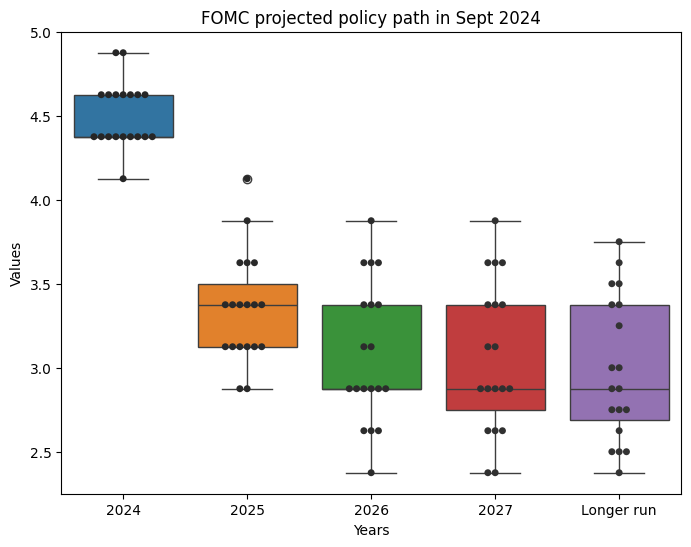

In [12]:
# Step 9: Visualize in a boxplot using Matplotlib and Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Create a multi-boxplot with data points shown as dots
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, showfliers=True)
sns.swarmplot(data=df, palette="dark:.2")

# Customize the plot labels and title
plt.title("FOMC projected policy path in Sept 2024")
plt.ylabel("Values")
plt.xlabel("Years")

# Show the plot
plt.show()

<ipython-input-13-3ffa4cc83a11>:62: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rates += [np.nan] * (data.sum()[0] - len(rates))
<ipython-input-13-3ffa4cc83a11>:62: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rates += [np.nan] * (data.sum()[0] - len(rates))
<ipython-input-13-3ffa4cc83a11>:62: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rates += [np.nan] * (data.sum()[0] - len(rates))


,2024,2025,Longer run,date,2027
0,5.375,5.375,3.750,2024-03-20,NaN
1,5.375,4.375,3.500,2024-03-20,NaN
2,5.125,4.375,3.500,2024-03-20,NaN
3,5.125,4.125,3.125,2024-03-20,NaN
4,4.875,3.875,3.000,2024-03-20,NaN
5,4.875,3.875,3.000,2024-03-20,NaN
6,4.875,3.875,3.000,2024-03-20,NaN
7,4.875,3.875,2.750,2024-03-20,NaN
8,4.875,3.875,2.625,2024-03-20,NaN
9,4.625,3.875,2.500,2024-03-20,NaN


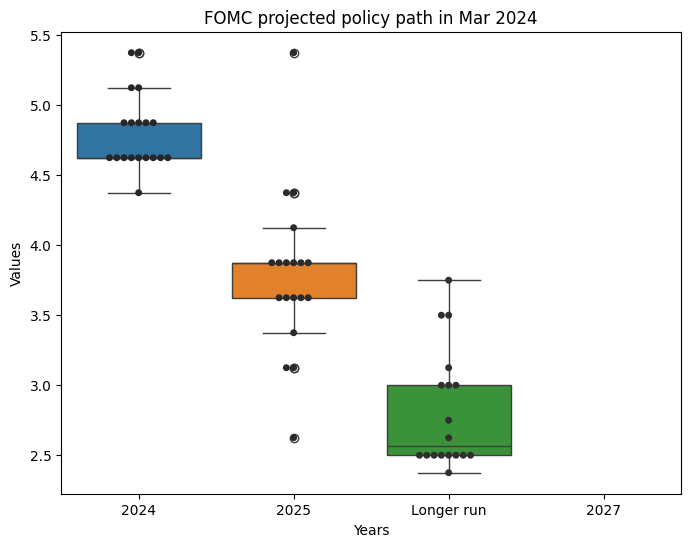

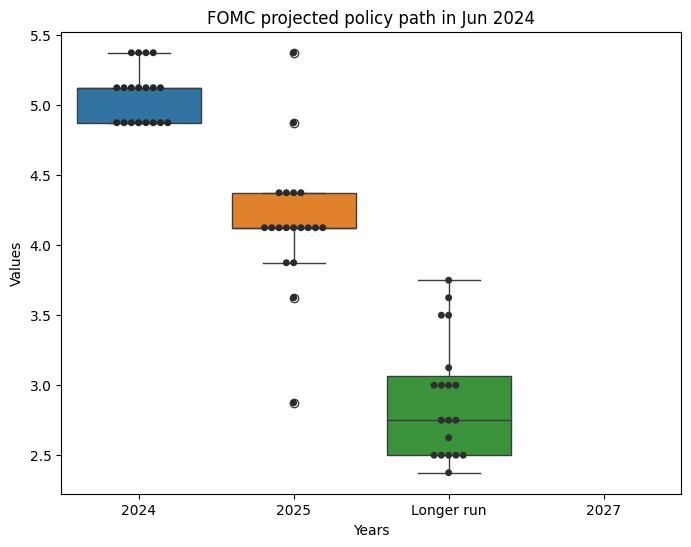

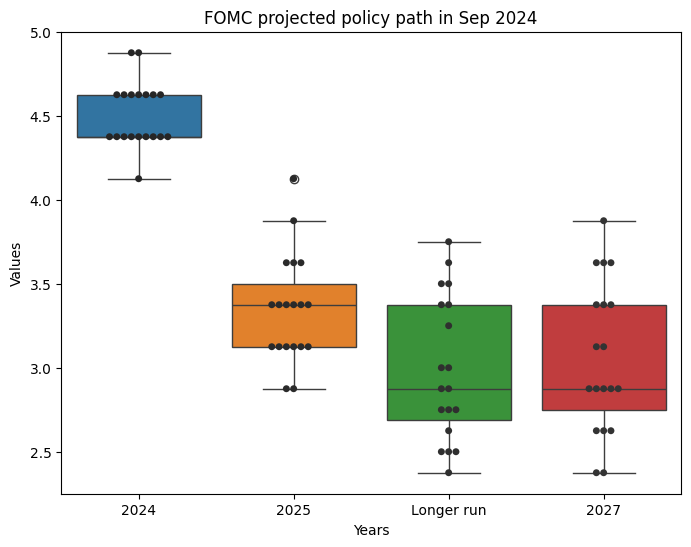

In [13]:
# Optional: Extra credit - extract all FOMC tables for all dates

import requests
from bs4 import BeautifulSoup
from datetime import date
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Scrape the initial page to find links
url = "https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm"
page = requests.get(url)
soup = BeautifulSoup(page.content, features="lxml")
links = soup.select(f'a[href^="/monetarypolicy/fomcprojtabl{date.today().year-1}"]')
links += soup.select(f'a[href^="/monetarypolicy/fomcprojtabl{date.today().year}"]')

df = pd.DataFrame()

# Step 2: Loop through the latest 3 links and extract data from each
for link in links[-3:]:
    url = f"https://www.federalreserve.gov{link['href']}"
    page = requests.get(url)
    soup = BeautifulSoup(page.content, features="lxml")

    # Step 3: Check for table using different aria attributes
    if len(soup.select('table[aria-describedby="xt6 xt6p1b"]')) != 0:
        table = soup.select('table[aria-describedby="xt6 xt6p1b"]')
    else:
        table = soup.select('table[aria-labelledby="xt6 xt6p1b"]')

    # Step 4: Extract headers and index
    headers = []
    index = []

    for i in table[0].find_all("th", {"class": "colhead"}):
        title = i.text
        headers.append(title)

    for i in table[0].find_all("th", {"class": "stub"}):
        title = i.text
        index.append(title)

    data = pd.DataFrame(columns=headers[1:])
    df_sub = pd.DataFrame(columns=headers[1:])

    # Step 5: Fill the data
    for j in table[0].find_all("tr")[1:]:
        row_data = j.find_all("td")
        row = [i.text.replace("\xa0", "") for i in row_data]
        length = len(data)
        data.loc[length] = row

    data = data.replace("", 0).astype(int)
    data.index = index

    # Step 6: Multiply rates with the frequency
    for col in data.columns:
        rates = []
        for i in data[col].index:
            rates += [float(i)] * data.loc[i, col]
        rates += [np.nan] * (data.sum()[0] - len(rates))
        df_sub[col] = rates

    # Step 7: Add a new column to indicate which FOMC
    df_sub["date"] = pd.to_datetime(str(link).split(".")[0][-8:])
    df = pd.concat([df, df_sub], ignore_index=True)

df = df.drop('2026', axis=1)

# The final DataFrame 'df' contains the scraped and processed data
display(df)

# Step 8: Visualize!
for date in df["date"].unique():
    # Create a multi-boxplot with data points shown as dots
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df[df["date"] == date], showfliers=True)
    sns.swarmplot(data=df[df["date"] == date], palette="dark:.2")

    # Customize the plot labels and title
    plt.title(f"FOMC projected policy path in {pd.to_datetime(date).strftime('%b %Y')}")
    plt.ylabel("Values")
    plt.xlabel("Years")

    # Show the plot
    plt.show()